# 02 · Cleaning & EDA

**Input:** `data/raw/rdu_ghcnh_2015-01-01_to_2026-09-16.csv` (produced by `01_data_sourcing.ipynb`)
**Output:** a cleaned, gap-aware hourly table saved under `data/interim/` for feature engineering (`03`)

| Section | Content |
|---|---|
| 1 | Setup, time boundaries, hourly time axis |
| 2 | Column selection and source-era audit |
| 3 | Cleaning with source-specific quality codes |
| 4 | Physical checks, sentinel values, spike detection |
| 5 | Assemble, split, export |
| 6 | EDA (training period only) |
| 7 | Summary and handoff |

The raw CSV is never modified. Rejected values are replaced with `NaN`, while the original value and the rejection reason are kept.

## 1. Setup and time boundaries

- **Target:** hourly `temperature` (°C) at RDU.
- **Forecast window:** 12am Sep 17 – 11pm Sep 30, 2026 (Eastern) → 336 hours. Only data before 12am Sep 17 may be used.
- **Validation window:** the 14 days right before the forecast start (Sep 3 – Sep 16). It mimics the real task and is excluded from EDA.
- **Time zone:** the index is UTC (unique and continuous); Eastern time is used to interpret local hour and month.

In [29]:
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# Paths: locate the project root dynamically so the notebook runs on any machine
current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "rdu_ghcnh_2015-01-01_to_2026-09-16.csv"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Time boundaries (Eastern time; the canonical index is UTC)
NY = ZoneInfo("America/New_York")
STATION_ID = "USW00013722"
DATA_START = pd.Timestamp("2015-01-01", tz=NY)
FORECAST_START = pd.Timestamp("2026-09-17", tz=NY)  # 12am Sep 17 (first forecast hour)
FORECAST_END = pd.Timestamp("2026-10-01", tz=NY)    # exclusive -> last forecast hour is 11pm Sep 30
VALIDATION_START = FORECAST_START - pd.Timedelta(days=14)

forecast_hours = pd.date_range(
    FORECAST_START.tz_convert("UTC"), FORECAST_END.tz_convert("UTC"),
    freq="h", inclusive="left", name="hour_utc",
)
assert len(forecast_hours) == 336


def save_fig(fig, name):
    """Save a figure to reports/figures for the slides and write-up."""
    fig.savefig(FIG_DIR / f"02_{name}.png", dpi=150, bbox_inches="tight")


raw = pd.read_csv(RAW_FILE, low_memory=False)

print(f"Source file : {RAW_FILE.relative_to(PROJECT_ROOT)}")
print(f"Raw shape   : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Validation  : {VALIDATION_START:%Y-%m-%d %H:%M} -> {FORECAST_START:%Y-%m-%d %H:%M} (exclusive)")
print(f"Forecast    : {FORECAST_START:%Y-%m-%d %H:%M} -> {FORECAST_END:%Y-%m-%d %H:%M} (exclusive), {len(forecast_hours)} hours")

Source file : data/raw/rdu_ghcnh_2015-01-01_to_2026-09-16.csv
Raw shape   : 102,471 rows x 226 columns
Validation  : 2026-09-03 00:00 -> 2026-09-17 00:00 (exclusive)
Forecast    : 2026-09-17 00:00 -> 2026-10-01 00:00 (exclusive), 336 hours


### 1.1 Timestamp checks and hour labels

Every observation is recorded at minute :51. Each one is labeled with the hour it belongs to (e.g. `00:51` → hour `00`), and the exact observation time is kept in `observation_utc`.

When daylight saving time ends, local clock times repeat (two `01:00` on the first Sunday of November). In UTC they are distinct, which is why UTC is the index.

In [30]:
observation_utc = pd.to_datetime(raw["DATE"], utc=True, errors="raise")

checks = {
    "single station (RDU)": raw["STATION"].eq(STATION_ID).all(),
    "all FM15 routine hourly reports": raw["temperature_Report_Type"].eq("FM15").all(),
    "all observed at minute :51": observation_utc.dt.minute.eq(51).all(),
    "UTC timestamps unique": observation_utc.is_unique,
    "sorted by time": observation_utc.is_monotonic_increasing,
    "nothing before data start": (observation_utc >= DATA_START).all(),
    "nothing at/after forecast start": (observation_utc < FORECAST_START).all(),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), "A sanity check failed - investigate before cleaning."

# Label each :51 observation with the hour it belongs to (00:51 -> hour 00)
observed = raw.copy()
observed["observation_utc"] = observation_utc
observed.index = pd.DatetimeIndex(observation_utc.dt.floor("h"), name="hour_utc")
observed["hour_local"] = observed.index.tz_convert(NY)
assert observed.index.is_unique

# DST: offset-free local clock times repeat in November, UTC does not
local_naive = observed["hour_local"].dt.tz_localize(None)
repeated_local = observed.loc[local_naive.duplicated(keep=False), ["observation_utc", "hour_local", "temperature"]]
print(f"Repeated local clock hours (DST fall-back): {local_naive.duplicated().sum()}  -> example:")
display(repeated_local.head(2))

,passed
single station (RDU),True
all FM15 routine hourly reports,True
all observed at minute :51,True
UTC timestamps unique,True
sorted by time,True
nothing before data start,True
nothing at/after forecast start,True


Repeated local clock hours (DST fall-back): 11  -> example:


,observation_utc,hour_local,temperature
hour_utc,,,
2015-11-01 05:00:00+00:00,2015-11-01 05:51:00+00:00,2015-11-01 01:00:00-04:00,14.400
2015-11-01 06:00:00+00:00,2015-11-01 06:51:00+00:00,2015-11-01 01:00:00-05:00,14.400


### 1.2 Complete hourly grid and gaps

Missing *rows* (hours with no report at all) are invisible to `isna()`. Comparing the observed hours with a complete UTC hourly grid reveals them. Consecutive missing hours are grouped into gaps.

Missing timestamps are added in Section 5, but missing temperatures are never interpolated in the cleaned table.

Expected hours        : 102,647
Observed hours        : 102,471
Missing hours         : 176 in 59 gaps (longest 90 h)
Missing in validation : 0 of 336
Last observation      : 2026-09-16 23:00 EDT


,number_of_gaps
missing_hours,
1 h,41
2-3 h,15
4-24 h,2
> 24 h,1


,start_local,end_local,missing_hours
0,2025-08-29 19:00:00-04:00,2025-09-02 12:00:00-04:00,90
1,2026-03-26 13:00:00-04:00,2026-03-26 19:00:00-04:00,7
2,2025-03-28 22:00:00-04:00,2025-03-29 01:00:00-04:00,4
3,2025-09-08 17:00:00-04:00,2025-09-08 19:00:00-04:00,3
4,2025-01-23 02:00:00-05:00,2025-01-23 04:00:00-05:00,3


,expected_hours,observed_hours,missing_hours,coverage_pct
local_year,,,,
2015,8760,8760,0,100.000
2016,8784,8781,3,99.970
2017,8760,8757,3,99.970
2018,8760,8757,3,99.970
2019,8760,8759,1,99.990
2020,8784,8784,0,100.000
2021,8760,8756,4,99.950
2022,8760,8760,0,100.000
2023,8760,8760,0,100.000


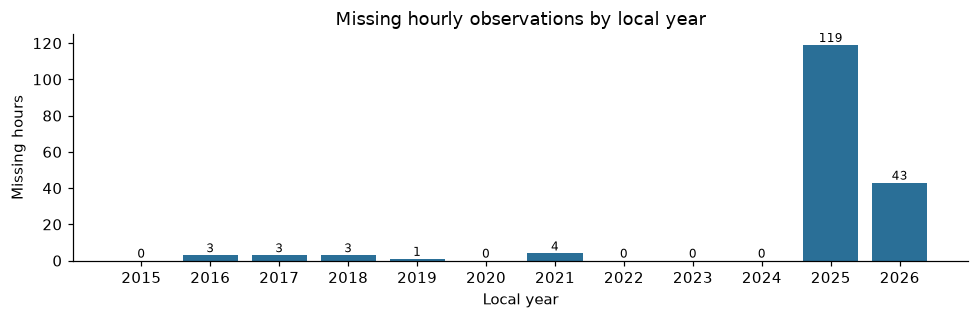

In [31]:
hour_index = pd.date_range(
    DATA_START.tz_convert("UTC"), FORECAST_START.tz_convert("UTC"),
    freq="h", inclusive="left", name="hour_utc",
)
assert observed.index.isin(hour_index).all()
missing_hours = hour_index.difference(observed.index)

# Group consecutive missing hours into gaps
gaps = pd.DataFrame({"hour_utc": missing_hours})
gaps["gap_id"] = gaps["hour_utc"].diff().ne(pd.Timedelta(hours=1)).cumsum()
gap_summary = (
    gaps.groupby("gap_id")["hour_utc"]
    .agg(start_utc="min", end_utc="max", missing_hours="size")
    .assign(
        start_local=lambda d: d["start_utc"].dt.tz_convert(NY),
        end_local=lambda d: d["end_utc"].dt.tz_convert(NY),
    )
    .sort_values("missing_hours", ascending=False)
    .reset_index(drop=True)
)
assert gap_summary["missing_hours"].sum() == len(missing_hours)

gap_length_counts = (
    pd.cut(gap_summary["missing_hours"], bins=[0, 1, 3, 24, np.inf],
           labels=["1 h", "2-3 h", "4-24 h", "> 24 h"])
    .value_counts().sort_index().rename("number_of_gaps").to_frame()
)

coverage = pd.Series(hour_index.isin(observed.index), index=hour_index)
coverage_by_year = coverage.groupby(hour_index.tz_convert(NY).year).agg(
    expected_hours="size", observed_hours="sum",
)
coverage_by_year["missing_hours"] = coverage_by_year["expected_hours"] - coverage_by_year["observed_hours"]
coverage_by_year["coverage_pct"] = (100 * coverage_by_year["observed_hours"] / coverage_by_year["expected_hours"]).round(2)
coverage_by_year.index.name = "local_year"

validation_hours = hour_index[hour_index >= VALIDATION_START]
print(f"Expected hours        : {len(hour_index):,}")
print(f"Observed hours        : {len(observed):,}")
print(f"Missing hours         : {len(missing_hours):,} in {len(gap_summary)} gaps "
      f"(longest {gap_summary['missing_hours'].max()} h)")
print(f"Missing in validation : {validation_hours.difference(observed.index).size} of {len(validation_hours)}")
print(f"Last observation      : {observed['hour_local'].max():%Y-%m-%d %H:%M %Z}")
display(gap_length_counts)
display(gap_summary[["start_local", "end_local", "missing_hours"]].head(5))
display(coverage_by_year)

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(coverage_by_year.index.astype(str), coverage_by_year["missing_hours"], color="#2a6f97")
for x, y in zip(coverage_by_year.index.astype(str), coverage_by_year["missing_hours"]):
    ax.text(x, y, str(y), ha="center", va="bottom", fontsize=8)
ax.set(title="Missing hourly observations by local year", xlabel="Local year", ylabel="Missing hours")
fig.tight_layout()
save_fig(fig, "missing_hours_by_year")
plt.show()

## 2. Column selection and source-era audit

The 226 columns are not 226 features. Each weather variable `X` comes with up to five metadata columns (`X_Measurement_Code`, `X_Quality_Code`, `X_Report_Type`, `X_Source_Code`, `X_Source_Station_ID`) that describe how it was measured and checked. Station and time columns are constant or duplicate the index.

In [32]:
METADATA_SUFFIXES = ("_Measurement_Code", "_Quality_Code", "_Report_Type", "_Source_Code", "_Source_Station_ID")
TIME_COLUMNS = {"DATE", "DATE_local", "Year", "Month", "Day", "Hour", "Minute"}
STATION_COLUMNS = {"STATION", "Station_name", "LATITUDE", "LONGITUDE", "ELEVATION"}


def column_role(column):
    if column in TIME_COLUMNS:
        return "time (redundant with index)"
    if column in STATION_COLUMNS:
        return "station (constant)"
    if column.endswith(METADATA_SUFFIXES):
        return "measurement metadata"
    if pd.api.types.is_numeric_dtype(raw[column]):
        return "numeric weather variable"
    return "text / coded weather variable"


column_roles = pd.Series({column: column_role(column) for column in raw.columns}, name="role")
display(column_roles.value_counts().rename("columns").to_frame())

VARIABLE_COLUMNS = column_roles.index[column_roles.str.contains("weather variable")].tolist()
print(f"{len(VARIABLE_COLUMNS)} weather variables; each comes with up to 5 metadata columns, e.g.:")
print([c for c in raw.columns if c.startswith("temperature")])

,columns
role,
measurement metadata,174
numeric weather variable,24
text / coded weather variable,16
time (redundant with index),7
station (constant),5


40 weather variables; each comes with up to 5 metadata columns, e.g.:
['temperature', 'temperature_Quality_Code', 'temperature_Report_Type', 'temperature_Source_Code', 'temperature_Source_Station_ID']


### 2.1 Source eras

`Source_Code` records which upstream data stream a value came from. The stream changed over time and the quality-code conventions changed with it, so cleaning rules must be applied per source. A record's era is defined by the source of its `temperature` value.

,rows,first_hour_local,last_hour_local,temperature_quality_code_supplied_pct
source_era,,,,
343,92687,2015-01-01 00:00:00-05:00,2025-08-26 23:00:00-04:00,100.000
223,5616,2015-02-27 23:00:00-05:00,2026-03-26 12:00:00-04:00,100.000
413,4168,2026-03-26 20:00:00-04:00,2026-09-16 23:00:00-04:00,0.000


source_era,343,223,413
local_year,,,
2015,8758,2,0
2016,8772,9,0
2017,8753,4,0
2018,8639,118,0
2019,8582,177,0
2020,8750,34,0
2021,8753,3,0
2022,8715,45,0
2023,8752,8,0


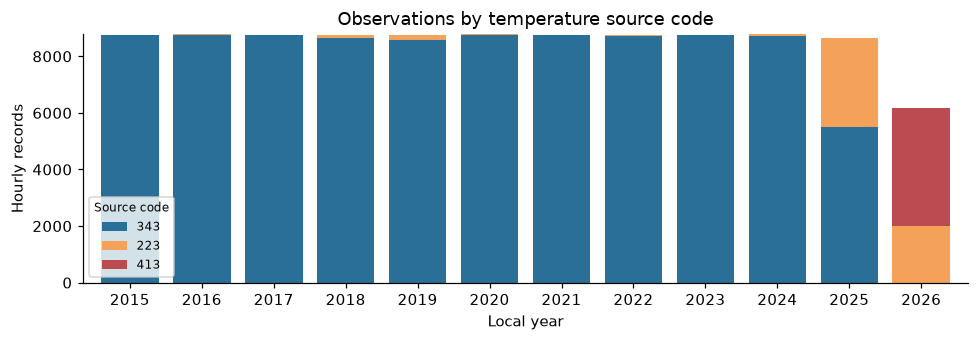

In [33]:
# A record's source era = the upstream source of its temperature value
observed["source_era"] = observed["temperature_Source_Code"].astype(str)

era_summary = (
    observed.groupby("source_era")
    .agg(
        rows=("temperature", "size"),
        first_hour_local=("hour_local", "min"),
        last_hour_local=("hour_local", "max"),
        temperature_quality_code_supplied_pct=(
            "temperature_Quality_Code", lambda codes: round(100 * codes.notna().mean(), 1)
        ),
    )
    .sort_values("first_hour_local")
)
ERA_ORDER = era_summary.index.tolist()
display(era_summary)

rows_by_year = pd.crosstab(observed["hour_local"].dt.year, observed["source_era"])[ERA_ORDER]
rows_by_year.index.name = "local_year"
display(rows_by_year)

fig, ax = plt.subplots(figsize=(9, 3.2))
rows_by_year.plot.bar(stacked=True, ax=ax, color=["#2a6f97", "#f4a259", "#bc4b51"], width=0.8)
ax.set(title="Observations by temperature source code", xlabel="Local year", ylabel="Hourly records")
ax.legend(title="Source code", fontsize=8, title_fontsize=8, loc="lower left")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
save_fig(fig, "source_eras_by_year")
plt.show()

### 2.2 Which variables to keep

The forecast starts from the most recent conditions, so a variable is only useful if it is still reported in the latest era (413). The audit shows the missing share per era for every weather variable, with a keep/drop decision and its reason. Dropped variables stay in the raw CSV and can be revisited.

The second table shows whether a quality code is supplied. Era 413 supplies none, so the physical checks in Section 4 are the only safeguard for the most recent six months.

In [34]:
import re

KEEP = {
    "temperature": "target",
    "dew_point_temperature": "complete in every era",
    "relative_humidity": "complete; derived from temperature and dew point",
    "sea_level_pressure": "nearly complete in every era",
    "altimeter": "complete in every era",
    "wind_speed": "complete in every era",
    "wind_direction": "complete; 999 means calm/variable (Section 4)",
    "visibility": "complete; capped at 16.09 km = 10 mi (Section 4)",
    "ceiling_height": "'no ceiling' is 22000 in era 343 but NaN later (Section 4)",
    "sky_cover_summation_1": "cloud-cover layer, complete; parsed to octas (Section 4)",
    "sky_cover_summation_2": "cloud-cover layer (only present when there is a 2nd layer)",
    "sky_cover_summation_3": "cloud-cover layer (only present when there is a 3rd layer)",
    "sky_cover_summation_4": "cloud-cover layer (only present when there is a 4th layer)",
}
DROP_RULES = [  # (regex on column name, reason)
    (r"station_level_pressure", "mostly missing since 2025 (eras 223/413)"),
    (r"wet_bulb_temperature", "mostly missing since 2025; derived from temperature/dew point"),
    (r"precipitation", "mostly missing since 2025 (eras 223/413)"),
    (r"precipitation_\d+_hour", "only reported at synoptic hours; > 96% missing"),
    (r"wind_gust", "only reported when gusts occur"),
    (r"pressure_3hr_change", "only reported every 3 h; recomputable from altimeter"),
    (r"snow_depth", "> 99% missing"),
    (r"sky_condition|sky_cover_layer_1", "sparse; sky_cover_summation_* is complete"),
    (r".*baseht.*", "cloud base heights; ceiling_height summarizes the relevant one"),
    (r"pres_wx_.*", "present-weather codes, only reported when weather occurs"),
    (r"REM", "raw METAR remark text"),
]


def decide(column):
    if column in KEEP:
        return "keep", KEEP[column]
    for pattern, reason in DROP_RULES:
        if re.fullmatch(pattern, column):
            return "drop", reason
    return "UNDECIDED", ""


missing_by_era = (
    observed[VARIABLE_COLUMNS].isna().groupby(observed["source_era"]).mean()
    .mul(100).round(1).T[ERA_ORDER].add_prefix("missing_pct_era_")
    .rename_axis(index="variable", columns=None)
)
decisions = pd.DataFrame([decide(c) for c in VARIABLE_COLUMNS], index=VARIABLE_COLUMNS, columns=["decision", "reason"])
variable_audit = missing_by_era.join(decisions).sort_values(["decision", "missing_pct_era_413"], ascending=[False, True])
assert not variable_audit["decision"].eq("UNDECIDED").any(), variable_audit.query("decision == 'UNDECIDED'")
with pd.option_context("display.max_rows", 100, "display.max_colwidth", 70):
    display(variable_audit)

MEASUREMENTS = [c for c in KEEP if not c.startswith("sky_cover_summation")]
CLOUD_COLUMNS = [c for c in KEEP if c.startswith("sky_cover_summation")]

# Quality codes: supplied in eras 343/223, empty in era 413 -> Section 4 must cover that era
qc_columns = [f"{v}_Quality_Code" for v in MEASUREMENTS if v != "relative_humidity"]
quality_code_supplied = (
    observed[qc_columns].notna().groupby(observed["source_era"]).mean()
    .mul(100).round(1).T[ERA_ORDER].add_prefix("qc_supplied_pct_era_")
    .rename(index=lambda name: name.removesuffix("_Quality_Code"))
    .rename_axis(index="variable", columns=None)
)
display(quality_code_supplied)
print(f"Keeping {len(MEASUREMENTS)} numeric measurements + {len(CLOUD_COLUMNS)} cloud-cover columns; "
      f"dropping {variable_audit['decision'].eq('drop').sum()} variables.")

,missing_pct_era_343,missing_pct_era_223,missing_pct_era_413,decision,reason
variable,,,,,
temperature,0.000,0.000,0.000,keep,target
dew_point_temperature,0.000,0.000,0.000,keep,complete in every era
relative_humidity,0.000,0.000,0.000,keep,complete; derived from temperature and dew point
visibility,0.000,0.000,0.000,keep,complete; capped at 16.09 km = 10 mi (Section 4)
altimeter,0.000,0.000,0.000,keep,complete in every era
sky_cover_summation_1,0.000,14.200,0.000,keep,"cloud-cover layer, complete; parsed to octas (Section 4)"
wind_speed,0.000,0.000,0.100,keep,complete in every era
sea_level_pressure,0.800,0.300,3.400,keep,nearly complete in every era
wind_direction,0.000,0.000,5.400,keep,complete; 999 means calm/variable (Section 4)


,qc_supplied_pct_era_343,qc_supplied_pct_era_223,qc_supplied_pct_era_413
variable,,,
temperature,100.000,100.000,0.000
dew_point_temperature,100.000,100.000,0.000
sea_level_pressure,99.200,99.700,0.000
altimeter,100.000,100.000,0.000
wind_speed,100.000,100.000,0.000
wind_direction,100.000,72.400,0.000
visibility,100.000,100.000,0.000
ceiling_height,100.000,69.800,0.000


Keeping 9 numeric measurements + 4 cloud-cover columns; dropping 27 variables.


## 3. Cleaning with source-specific quality codes

A quality code only has meaning together with its source code: the same digit means different things for different sources. The rules below follow Section VI of the [GHCNh documentation](https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/doc/ghcnh_DOCUMENTATION.pdf).

| Source | Codes kept | Codes rejected |
|---|---|---|
| ISD sources 313–346 (here: 343) | 0, 1, 4, 5, 9 passed checks · A suspect but accepted as good · U, P, I, M, R edited or replaced by a validator | 2, 6 suspect · 3, 7 erroneous |
| Legacy sources 220–223, 347, 348 (here: 223) | 0 not checked · 1 good · 4 calculated | 2 suspect · 3 erroneous · 5 removed |
| GHCNh's own QC (temperature, dew point, pressures, wind) | – | any lowercase letter = failed a GHCNh check |
| Derived relative humidity | – | o out of range · f an input measurement was flagged |
| Sources 412 / 413 | no codes supplied | handled by the physical checks in Section 4 |

- A missing quality code is treated as neither a failure nor a pass.
- Rejected values become `NaN` in `cleaned`. The original values stay untouched in `observed`, and every rejection is recorded in `rejection_log` with its reason.

### 3.1 Code inventory

Every (variable, source, quality code) combination that actually occurs, with its meaning and decision. The `assert` stops the notebook if a code appears that the rules do not cover.

In [35]:
# Quality-code rules from the GHCNh documentation, Section VI
ISD_SOURCES = {"313", "314", "315", "322", "335", "343", "344", "346"}
LEGACY_SOURCES = {"220", "221", "222", "223", "347", "348"}
ISD_REJECT = {"2", "3", "6", "7"}   # suspect / erroneous
LEGACY_REJECT = {"2", "3", "5"}     # suspect / erroneous / removed
GHCNH_QC_VARIABLES = {               # variables checked by GHCNh's own QC (lowercase letter = failed a check)
    "temperature", "dew_point_temperature", "station_level_pressure",
    "sea_level_pressure", "wind_direction", "wind_speed",
}
DERIVED_REJECT = {"o", "f"}          # relative humidity: out of range / an input measurement was flagged

CODE_MEANING = {
    "ISD": {"0": "passed gross limits", "1": "passed all QC", "2": "suspect", "3": "erroneous",
            "4": "passed gross limits (NCEI)", "5": "passed all QC (NCEI)", "6": "suspect (NCEI)",
            "7": "erroneous (NCEI)", "9": "passed gross limits if present",
            "A": "suspect, but accepted as good", "U": "replaced with edited value",
            "P": "replaced by validator", "I": "inserted by validator",
            "M": "manual change (NWS/FAA)", "R": "replaced with NCEI computed value"},
    "LEGACY": {"0": "not checked", "1": "good", "2": "suspect", "3": "erroneous",
               "4": "calculated", "5": "removed"},
    "DERIVED": {"o": "out of range (< 1 or > 100)", "f": "an input measurement was flagged"},
}
QC_VARIABLES = MEASUREMENTS + CLOUD_COLUMNS


def as_code(series):
    """Normalize a code column to strings without a trailing '.0' ('' when missing)."""
    return series.astype("string").str.replace(r"\.0$", "", regex=True).fillna("")


def qc_reject_mask(frame, variable):
    """True where the source-specific quality code marks a present value as bad."""
    source = as_code(frame[f"{variable}_Source_Code"])
    quality = as_code(frame[f"{variable}_Quality_Code"])
    reject = (
        (source.isin(ISD_SOURCES) & quality.isin(ISD_REJECT))
        | (source.isin(LEGACY_SOURCES) & quality.isin(LEGACY_REJECT))
    )
    if variable in GHCNH_QC_VARIABLES:
        reject |= quality.str.contains(r"[a-z]", regex=True)
    if variable == "relative_humidity":
        reject |= quality.isin(DERIVED_REJECT)
    return reject & frame[variable].notna()


def code_meaning(variable, source, quality):
    if quality == "":
        return "no code supplied"
    if variable == "relative_humidity" and quality in CODE_MEANING["DERIVED"]:
        return CODE_MEANING["DERIVED"][quality]
    if quality.islower():
        return "failed a GHCNh QC check"
    family = "ISD" if source in ISD_SOURCES else "LEGACY" if source in LEGACY_SOURCES else None
    return CODE_MEANING.get(family, {}).get(quality, "unmapped - review")


# Inventory: every (variable, source, quality code) combination that occurs, with its decision
inventory_parts = []
for variable in QC_VARIABLES:
    present = observed[variable].notna()
    inventory_parts.append(pd.DataFrame({
        "variable": variable,
        "source": as_code(observed.loc[present, f"{variable}_Source_Code"]),
        "quality": as_code(observed.loc[present, f"{variable}_Quality_Code"]),
        "rejected": qc_reject_mask(observed, variable)[present],
    }))
code_inventory = pd.concat(inventory_parts).value_counts().rename("values").reset_index()
code_inventory["variable"] = pd.Categorical(code_inventory["variable"], categories=QC_VARIABLES, ordered=True)
code_inventory = code_inventory.sort_values(["variable", "values"], ascending=[True, False]).reset_index(drop=True)
code_inventory["meaning"] = [code_meaning(*row) for row in code_inventory[["variable", "source", "quality"]].itertuples(index=False)]
code_inventory["decision"] = np.where(code_inventory["rejected"], "REJECT", "keep")
code_inventory = code_inventory.drop(columns="rejected")
assert not code_inventory["meaning"].eq("unmapped - review").any(), code_inventory.query("meaning == 'unmapped - review'")
with pd.option_context("display.max_rows", 120):
    display(code_inventory)

,variable,source,quality,values,meaning,decision
0,temperature,343,5,92659,passed all QC (NCEI),keep
1,temperature,223,1,5597,good,keep
2,temperature,413,,4168,no code supplied,keep
3,temperature,223,4,19,calculated,keep
4,temperature,343,A,16,"suspect, but accepted as good",keep
5,temperature,343,P,4,replaced by validator,keep
6,temperature,343,6,4,suspect (NCEI),REJECT
7,temperature,343,7,4,erroneous (NCEI),REJECT
8,dew_point_temperature,343,5,92668,passed all QC (NCEI),keep
9,dew_point_temperature,223,1,5595,good,keep


### 3.2 Apply the rules

Rejected values are masked and counted per variable. The rejected temperatures are shown next to the neighbouring raw hours for a sanity check.

In [36]:
cleaned = observed[["observation_utc", "hour_local", "source_era"]].copy()
log_parts = []
for variable in QC_VARIABLES:
    reject = qc_reject_mask(observed, variable)
    cleaned[variable] = observed[variable].mask(reject)
    log_parts.append(pd.DataFrame({
        "variable": variable,
        "original_value": observed.loc[reject, variable].astype(str),
        "source": as_code(observed.loc[reject, f"{variable}_Source_Code"]),
        "quality": as_code(observed.loc[reject, f"{variable}_Quality_Code"]),
        "reason": "quality code",
    }))
rejection_log = pd.concat(log_parts).sort_index()

qc_summary = pd.DataFrame({
    "values_present": observed[QC_VARIABLES].notna().sum(),
    "rejected_by_qc_code": rejection_log["variable"].value_counts().reindex(QC_VARIABLES, fill_value=0),
    "values_after_qc": cleaned[QC_VARIABLES].notna().sum(),
})
qc_summary["rejected_pct"] = (100 * qc_summary["rejected_by_qc_code"] / qc_summary["values_present"]).round(3)
assert (qc_summary["values_present"] - qc_summary["rejected_by_qc_code"]).eq(qc_summary["values_after_qc"]).all()
display(qc_summary)

# Rejected temperatures shown next to the neighbouring hours
temperature_grid = observed["temperature"].reindex(hour_index)
rejected_temperature = rejection_log.query("variable == 'temperature'").index
temperature_context = pd.DataFrame({
    "hour_local": rejected_temperature.tz_convert(NY),
    "previous_hour_raw": temperature_grid.shift(1).loc[rejected_temperature].to_numpy(),
    "rejected_value": observed.loc[rejected_temperature, "temperature"].to_numpy(),
    "next_hour_raw": temperature_grid.shift(-1).loc[rejected_temperature].to_numpy(),
    "quality": rejection_log.query("variable == 'temperature'")["quality"].to_numpy(),
})
display(temperature_context)

,values_present,rejected_by_qc_code,values_after_qc,rejected_pct
temperature,102471,8,102463,0.008
dew_point_temperature,102471,7,102464,0.007
relative_humidity,102471,14,102457,0.014
sea_level_pressure,101614,1,101613,0.001
altimeter,102471,1,102470,0.001
wind_speed,102448,4,102444,0.004
wind_direction,102230,2,102228,0.002
visibility,102461,33,102428,0.032
ceiling_height,98868,148,98720,0.150
sky_cover_summation_1,101669,13,101656,0.013


,hour_local,previous_hour_raw,rejected_value,next_hour_raw,quality
0,2024-12-27 05:00:00-05:00,4.400,4.000,4.400,6
1,2024-12-27 06:00:00-05:00,4.000,4.400,5.000,6
2,2024-12-28 08:00:00-05:00,8.300,9.000,12.000,7
3,2024-12-28 09:00:00-05:00,9.000,12.000,14.400,7
4,2025-01-29 06:00:00-05:00,2.800,3.300,3.900,6
5,2025-02-07 10:00:00-05:00,16.700,19.000,20.600,7
6,2025-03-16 20:00:00-04:00,21.700,22.000,20.000,7
7,2025-03-23 09:00:00-04:00,10.000,15.600,17.200,6


## 4. Physical checks, special values and spike detection

Era 413 covers the last six months before the forecast start and carries no quality codes, so it needs independent checks. All rules below use fixed physical thresholds set in advance (nothing is tuned on the data or the validation window) and are applied to every era.

1. **Special values**: codes that look like numbers but are not measurements are recoded (not counted as errors).
2. **Physical limits and consistency**: impossible values are rejected.
3. **Spikes and flatlines**: one-hour jumps that immediately reverse, and stuck sensors.

Rejections are recorded in the same `rejection_log` as in Section 3.

### 4.1 Special values

- **Wind direction 999** is not an angle: with wind speed 0 it means calm, otherwise a variable direction. The direction becomes `NaN`, and two flags keep the information: `wind_calm` and `wind_direction_variable`. A direction reported together with zero wind speed is also undefined.
- **Cloud cover**: each `sky_cover_summation_k` layer looks like `BKN:07;`, where the number is the cumulative sky-cover code (CLR 0, FEW 2, SCT 4, BKN 7, OVC 8, VV 9 = sky obscured → 8). Total cloud cover is the highest code across layers, stored as `cloud_cover_octas`.
- **Ceiling**: "no ceiling" is coded as 22000 m in era 343 but left empty in eras 223/413. A ceiling requires a broken or overcast layer, so an empty ceiling under ≤ 4 octas is set to 22000 m and flagged `no_ceiling`. Empty ceilings under broken/overcast skies remain missing.

In [37]:
NO_CEILING_M = 22000
COVER_CODE_TO_OCTAS = {0: 0, 2: 2, 4: 4, 7: 7, 8: 8, 9: 8}  # CLR, FEW, SCT, BKN, OVC, VV (sky obscured); X:10 -> NaN

# Cloud cover: total cover = highest cumulative cover code across the reported layers
layer_codes = pd.concat(
    [cleaned[c].str.extract(r":(\d+)", expand=False).astype(float) for c in CLOUD_COLUMNS], axis=1
)
cleaned["cloud_cover_octas"] = layer_codes.max(axis=1).map(COVER_CODE_TO_OCTAS)

# Wind direction: 999 is not an angle (calm if speed is 0, otherwise variable); direction is undefined when calm
direction = cleaned["wind_direction"]
cleaned["wind_calm"] = cleaned["wind_speed"].eq(0)
cleaned["wind_direction_variable"] = direction.eq(999) & cleaned["wind_speed"].gt(0)
cleaned["wind_direction"] = direction.mask(direction.eq(999) | cleaned["wind_calm"])

# Ceiling: era 343 codes "no ceiling" as 22000 m, eras 223/413 leave it empty.
# A ceiling needs a broken/overcast layer, so an empty ceiling under <= 4 octas means "no ceiling".
ceiling_filled = cleaned["ceiling_height"].isna() & cleaned["cloud_cover_octas"].le(4)
cleaned.loc[ceiling_filled, "ceiling_height"] = NO_CEILING_M
cleaned["no_ceiling"] = cleaned["ceiling_height"].eq(NO_CEILING_M)

recode_summary = pd.DataFrame({
    "wind_direction 999 -> NaN, calm": (direction.eq(999) & cleaned["wind_calm"]).groupby(cleaned["source_era"]).sum(),
    "wind_direction 999 -> NaN, variable": cleaned["wind_direction_variable"].groupby(cleaned["source_era"]).sum(),
    "wind_direction 0-360 with calm -> NaN": (direction.between(0, 360) & cleaned["wind_calm"]).groupby(cleaned["source_era"]).sum(),
    "ceiling empty -> 22000 (no ceiling)": ceiling_filled.groupby(cleaned["source_era"]).sum(),
}).T[ERA_ORDER]
recode_summary["total"] = recode_summary.sum(axis=1)
display(recode_summary)

cloud_check = pd.crosstab(cleaned["cloud_cover_octas"].fillna(-1), cleaned["source_era"])[ERA_ORDER]
cloud_check.index = cloud_check.index.map(lambda v: "missing" if v == -1 else f"{int(v)} octas")
display(cloud_check)

cleaned = cleaned.drop(columns=CLOUD_COLUMNS)
MEASUREMENTS_CLEAN = MEASUREMENTS + ["cloud_cover_octas"]

source_era,343,223,413,total
"wind_direction 999 -> NaN, calm",20850,1265,0,22115
"wind_direction 999 -> NaN, variable",6792,331,0,7123
wind_direction 0-360 with calm -> NaN,0,0,652,652
ceiling empty -> 22000 (no ceiling),7,1672,1907,3586


source_era,343,223,413
cloud_cover_octas,,,
missing,6,799,0
0 octas,9362,0,300
2 octas,17278,1167,842
4 octas,13302,669,765
7 octas,29592,1420,1534
8 octas,23147,1561,727


### 4.2 Physical limits and consistency

Limits are deliberately wide: only impossible values are removed, and extreme but real weather stays. The dew point cannot exceed the air temperature; when it does, the dew point (and relative humidity) is rejected while the target temperature is kept.

In [38]:
def reject(variable, mask, reason):
    """Set flagged values to NaN in `cleaned` and append them to `rejection_log` (idempotent on re-run)."""
    global rejection_log
    mask = mask & cleaned[variable].notna()
    if mask.any():
        source_column, quality_column = f"{variable}_Source_Code", f"{variable}_Quality_Code"
        rejection_log = pd.concat([rejection_log, pd.DataFrame({
            "variable": variable,
            "original_value": cleaned.loc[mask, variable].astype(str),
            "source": as_code(observed.loc[mask, source_column]) if source_column in observed else "",
            "quality": as_code(observed.loc[mask, quality_column]) if quality_column in observed else "",
            "reason": reason,
        })]).sort_index()
        cleaned.loc[mask, variable] = np.nan
    return int(mask.sum())


PHYSICAL_LIMITS = {  # gross limits for RDU (wide on purpose: only impossible values are removed)
    "temperature": (-30, 45),
    "dew_point_temperature": (-40, 35),
    "relative_humidity": (1, 100),
    "sea_level_pressure": (950, 1060),
    "altimeter": (950, 1060),
    "wind_speed": (0, 50),
    "wind_direction": (0, 360),
    "visibility": (0, 16.1),          # reports are capped at 10 mi = 16.09 km
    "ceiling_height": (0, NO_CEILING_M),
    "cloud_cover_octas": (0, 8),
}
limit_rows = []
for variable, (lower, upper) in PHYSICAL_LIMITS.items():
    values = cleaned[variable]
    rejected = reject(variable, values.notna() & ~values.between(lower, upper), "outside physical limits")
    limit_rows.append({"variable": variable, "lower": lower, "upper": upper, "rejected": rejected})
display(pd.DataFrame(limit_rows).set_index("variable"))

# Consistency: the dew point cannot exceed the air temperature -> reject dew point (and RH), keep the target
dew_above_temperature = cleaned["dew_point_temperature"] > cleaned["temperature"]
print("Dew point above temperature:",
      reject("dew_point_temperature", dew_above_temperature, "dew point above temperature"), "dew point values,",
      reject("relative_humidity", dew_above_temperature, "dew point above temperature"), "RH values rejected")

,lower,upper,rejected
variable,,,
temperature,-30,45.000,0
dew_point_temperature,-40,35.000,0
relative_humidity,1,100.000,0
sea_level_pressure,950,"1,060.000",0
altimeter,950,"1,060.000",0
wind_speed,0,50.000,0
wind_direction,0,360.000,0
visibility,0,16.100,1
ceiling_height,0,"22,000.000",0


Dew point above temperature: 3 dew point values, 0 RH values rejected


### 4.3 Spikes and flatlines

A spike is a one-hour excursion that reverses in the next hour, measured on the complete hourly grid. Its size is the smaller of the jump in and the jump out.

- **Corrupted reports**: if at least two independent sensors spike in the same hour (temperature > 4 °C, dew point > 5 °C, pressure > 3 hPa), the whole report is rejected.
- **Single-variable spikes**: thresholds (temperature and dew point 8 °C, pressure 5 hPa, wind speed 15 m/s) are set well above typical reversing excursions from real weather such as thunderstorm cooling, so only physically implausible values are removed.
- **Flatlines**: identical values for ≥ 24 consecutive hours would indicate a stuck sensor.

In [39]:
SPIKE_LIMITS = {"temperature": 8.0, "dew_point_temperature": 8.0, "altimeter": 5.0,
                "sea_level_pressure": 5.0, "wind_speed": 15.0}
REPORT_SPIKE_LIMITS = {"temperature": 4.0, "dew_point_temperature": 5.0, "altimeter": 3.0}
FLATLINE_HOURS = 24


def spike_size(series):
    """Size of a one-hour excursion that reverses in the next hour (0 otherwise), on the full hourly grid."""
    x = series.reindex(hour_index)
    jump_in, jump_out = x - x.shift(1), x - x.shift(-1)
    size = np.minimum(jump_in.abs(), jump_out.abs()).where(np.sign(jump_in) == np.sign(jump_out), 0)
    return size.reindex(series.index)


# 1) Corrupted reports: at least two independent sensors spike in the same hour -> reject the whole report
report_spikes = sum(spike_size(cleaned[v]).gt(limit).astype(int) for v, limit in REPORT_SPIKE_LIMITS.items())
corrupted_report = report_spikes.ge(2)
for variable in MEASUREMENTS_CLEAN:
    reject(variable, corrupted_report, "multi-variable spike (corrupted report)")

# 2) Single-variable spikes that are physically implausible
for variable, limit in SPIKE_LIMITS.items():
    reject(variable, spike_size(cleaned[variable]).gt(limit), "one-hour spike")

# 3) Flatlines: identical values for >= 24 consecutive hours would mean a stuck sensor
flatline_rows = []
for variable in ["temperature", "dew_point_temperature", "altimeter"]:
    x = cleaned[variable].reindex(hour_index)
    run_id = x.ne(x.shift()).cumsum()
    run_length = x.groupby(run_id).transform("size").where(x.notna(), 0)
    flatline = run_length.ge(FLATLINE_HOURS).reindex(cleaned.index)
    flatline_rows.append({"variable": variable, "longest_run_hours": int(run_length.max()),
                          "rejected": reject(variable, flatline, f"flatline >= {FLATLINE_HOURS} h")})
display(pd.DataFrame(flatline_rows).set_index("variable"))

# Context for every spike rejection: raw neighbours on the full hourly grid
spike_log = rejection_log[rejection_log["reason"].str.contains("spike")]
spike_context = pd.DataFrame([
    {
        "hour_local": hour.tz_convert(NY), "variable": row.variable,
        "previous_hour_raw": observed[row.variable].reindex(hour_index).shift(1).get(hour),
        "rejected_value": float(row.original_value),
        "next_hour_raw": observed[row.variable].reindex(hour_index).shift(-1).get(hour),
        "source_era": observed.at[hour, "source_era"], "reason": row.reason,
    }
    for hour, row in spike_log.iterrows() if row.variable in observed
]).sort_values(["hour_local", "variable"], ignore_index=True)
display(spike_context)

,longest_run_hours,rejected
variable,,
temperature,21,0
dew_point_temperature,18,0
altimeter,11,0


,hour_local,variable,previous_hour_raw,rejected_value,next_hour_raw,source_era,reason
0,2019-03-01 11:00:00-05:00,altimeter,"1,020.700","1,027.100","1,020.000",343,multi-variable spike (corrupted report)
1,2019-03-01 11:00:00-05:00,ceiling_height,91.000,"22,000.000",91.000,343,multi-variable spike (corrupted report)
2,2019-03-01 11:00:00-05:00,dew_point_temperature,5.000,-1.700,5.000,343,multi-variable spike (corrupted report)
3,2019-03-01 11:00:00-05:00,relative_humidity,100.000,46.000,100.000,343,multi-variable spike (corrupted report)
4,2019-03-01 11:00:00-05:00,sea_level_pressure,"1,020.600","1,027.300","1,020.100",343,multi-variable spike (corrupted report)
5,2019-03-01 11:00:00-05:00,temperature,5.000,9.400,5.000,343,multi-variable spike (corrupted report)
6,2019-03-01 11:00:00-05:00,visibility,0.805,16.093,0.805,343,multi-variable spike (corrupted report)
7,2019-03-01 11:00:00-05:00,wind_direction,40.000,240.000,60.000,343,multi-variable spike (corrupted report)
8,2019-03-01 11:00:00-05:00,wind_speed,5.100,4.600,3.600,343,multi-variable spike (corrupted report)
9,2026-04-19 19:00:00-04:00,wind_speed,3.600,31.400,0.000,413,one-hour spike


### 4.4 Cleaning summary

Rejections per variable and reason, rejections per source era, and a before/after view of the two spike events.

reason,dew point above temperature,multi-variable spike (corrupted report),one-hour spike,outside physical limits,quality code,total
variable,,,,,,
temperature,0,1,0,0,8,9
dew_point_temperature,3,1,0,0,7,11
relative_humidity,0,1,0,0,14,15
sea_level_pressure,0,1,0,0,1,2
altimeter,0,1,0,0,1,2
wind_speed,0,1,1,0,4,6
wind_direction,0,1,0,0,2,3
visibility,0,1,0,1,33,35
ceiling_height,0,1,0,0,148,149


source_era,343,223,413
reason,,,
dew point above temperature,3,0,0
multi-variable spike (corrupted report),10,0,0
one-hour spike,0,0,1
outside physical limits,0,1,0
quality code,239,6,0


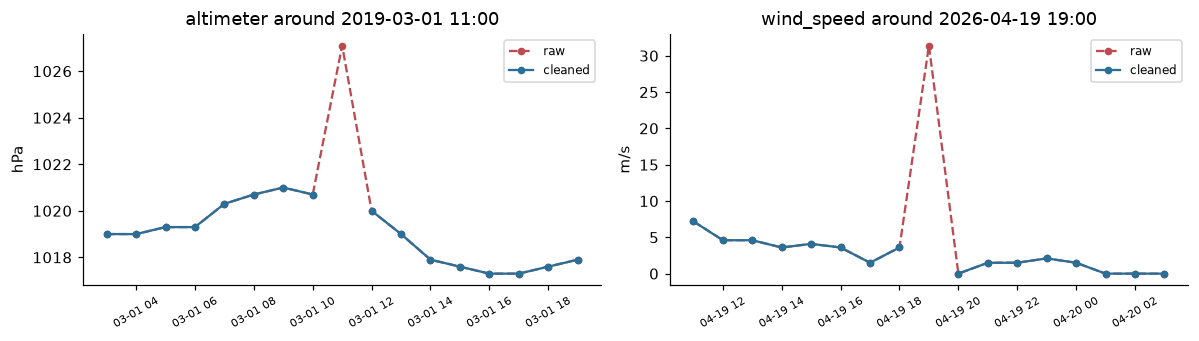

Rejection log: 260 values in total
Columns in `cleaned`: ['observation_utc', 'hour_local', 'source_era', 'temperature', 'dew_point_temperature', 'relative_humidity', 'sea_level_pressure', 'altimeter', 'wind_speed', 'wind_direction', 'visibility', 'ceiling_height', 'cloud_cover_octas', 'wind_calm', 'wind_direction_variable', 'no_ceiling']


In [40]:
rejection_counts = (
    rejection_log.pivot_table(index="variable", columns="reason", values="original_value", aggfunc="size", fill_value=0)
    .reindex(MEASUREMENTS_CLEAN + CLOUD_COLUMNS).dropna(how="all").fillna(0).astype(int)
)
rejection_counts["total"] = rejection_counts.sum(axis=1)
display(rejection_counts)

log_era = observed["source_era"].reindex(rejection_log.index).to_numpy()
rejections_by_era = pd.crosstab(rejection_log["reason"].to_numpy(), log_era, rownames=["reason"], colnames=["source_era"])
display(rejections_by_era.reindex(columns=ERA_ORDER, fill_value=0))

# Before/after for the two spike events
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, (variable, center, unit) in zip(axes, [("altimeter", "2019-03-01 16:00", "hPa"),
                                                ("wind_speed", "2026-04-19 23:00", "m/s")]):
    center = pd.Timestamp(center, tz="UTC")
    window = hour_index[(hour_index >= center - pd.Timedelta(hours=8)) & (hour_index <= center + pd.Timedelta(hours=8))]
    local_hours = window.tz_convert(NY)
    ax.plot(local_hours, observed[variable].reindex(window), "o--", color="#bc4b51", label="raw", markersize=4)
    ax.plot(local_hours, cleaned[variable].reindex(window), "o-", color="#2a6f97", label="cleaned", markersize=4)
    ax.set(title=f"{variable} around {center.tz_convert(NY):%Y-%m-%d %H:%M}", ylabel=unit)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "spike_examples")
plt.show()

print(f"Rejection log: {len(rejection_log)} values in total")
print("Columns in `cleaned`:", cleaned.columns.tolist())

## 5. Assemble, split and export

### 5.1 Complete hourly grid and train/validation partition

- `reindex` adds the 176 hours with no report as empty rows. No value is interpolated.
- `record_observed`: a report exists for that hour. `target_available`: a cleaned temperature exists.
- `temperature_raw` keeps the original temperature next to the cleaned `temperature`.
- `partition`: `train` before Sep 3, 2026; `validation` from Sep 3 to Sep 16 (336 hours). The EDA in Section 6 uses `train` only.

In [41]:
hourly = cleaned.reindex(hour_index)  # adds the hours with no report as empty rows; nothing is interpolated
hourly["hour_local"] = hourly.index.tz_convert(NY)
hourly["temperature_raw"] = observed["temperature"].reindex(hour_index)
hourly["record_observed"] = hourly.index.isin(observed.index)
hourly["target_available"] = hourly["temperature"].notna()
for flag in ["wind_calm", "wind_direction_variable", "no_ceiling"]:
    hourly[flag] = hourly[flag].astype("boolean")  # missing hours stay <NA> instead of False
hourly["partition"] = np.where(hourly.index < VALIDATION_START, "train", "validation")

split_summary = hourly.groupby("partition").agg(
    first_hour_local=("hour_local", "min"),
    last_hour_local=("hour_local", "max"),
    grid_hours=("temperature", "size"),
    observed_records=("record_observed", "sum"),
    usable_targets=("target_available", "sum"),
)
display(split_summary)

missing_target = pd.DataFrame({
    "no report for that hour": (~hourly["record_observed"]).groupby(hourly["partition"]).sum(),
    "rejected during cleaning": (hourly["record_observed"] & hourly["temperature"].isna()).groupby(hourly["partition"]).sum(),
}).T
missing_target["total"] = missing_target.sum(axis=1)
display(missing_target.rename_axis("missing temperature"))

,first_hour_local,last_hour_local,grid_hours,observed_records,usable_targets
partition,,,,,
train,2015-01-01 00:00:00-05:00,2026-09-02 23:00:00-04:00,102311,102135,102126
validation,2026-09-03 00:00:00-04:00,2026-09-16 23:00:00-04:00,336,336,336


partition,train,validation,total
missing temperature,,,
no report for that hour,176,0,176
rejected during cleaning,9,0,9


### 5.2 Final checks

These conditions must all hold before anything is written to disk; otherwise the `assert` stops the notebook.

In [42]:
usable = hourly["target_available"]
rejected_temperature_hours = rejection_log.query("variable == 'temperature'").index
final_checks = {
    "continuous, unique UTC hourly index": hourly.index.equals(hour_index),
    "no data at/after forecast start": hourly.index.max() < FORECAST_START,
    "empty rows carry no temperature": hourly.loc[~hourly["record_observed"], "temperature"].isna().all(),
    "cleaning only removed temperatures, never changed one": np.array_equal(
        hourly.loc[usable, "temperature"].to_numpy(), hourly.loc[usable, "temperature_raw"].to_numpy()),
    "every rejected temperature is NaN": hourly.loc[rejected_temperature_hours, "temperature"].isna().all(),
    "validation = 336 hours": hourly["partition"].eq("validation").sum() == 336,
    "train ends before validation starts": hourly.index[hourly["partition"].eq("train")].max() < VALIDATION_START,
    "temperature missing = gaps + rejections": hourly["temperature"].isna().sum()
        == len(missing_hours) + len(rejected_temperature_hours),
}
display(pd.Series(final_checks, name="passed").to_frame())
assert all(final_checks.values()), "A final check failed - do not export."

,passed
"continuous, unique UTC hourly index",True
no data at/after forecast start,True
empty rows carry no temperature,True
"cleaning only removed temperatures, never changed one",True
every rejected temperature is NaN,True
validation = 336 hours,True
train ends before validation starts,True
temperature missing = gaps + rejections,True


### 5.3 Export to `data/interim/`

| File | Content |
|---|---|
| `rdu_hourly_clean_2015-01-01_to_2026-09-16.csv` | one row per UTC hour, cleaned measurements and flags |
| `rdu_rejection_log.csv` | every rejected value with its original value, source, quality code and reason |

Columns of the clean table:

| Column | Meaning |
|---|---|
| `hour_utc` (index) | hour the observation belongs to, in UTC |
| `hour_local` | the same hour in US Eastern time |
| `observation_utc` | exact report time (minute :51) |
| `source_era` | source code of the temperature value (343 / 223 / 413) |
| `partition` | `train` or `validation` |
| `record_observed` | a report exists for this hour |
| `target_available` | a cleaned temperature exists |
| `temperature` | cleaned target (°C) |
| `temperature_raw` | original temperature before cleaning (°C) |
| `dew_point_temperature`, `relative_humidity` | °C, % |
| `sea_level_pressure`, `altimeter` | hPa |
| `wind_speed`, `wind_direction` | m/s, degrees (NaN when calm or variable) |
| `wind_calm`, `wind_direction_variable` | wind flags |
| `visibility` | km (capped at 16.09) |
| `ceiling_height`, `no_ceiling` | m (22000 = no ceiling), flag |
| `cloud_cover_octas` | total cloud cover, 0–8 |

Read it back with `pd.read_csv(path, index_col="hour_utc", parse_dates=["hour_utc"], dtype={"source_era": "string"})`. The file is read back below and compared with the in-memory table.

In [43]:
EXPORT_COLUMNS = [
    "hour_local", "observation_utc", "source_era", "partition", "record_observed", "target_available",
    "temperature", "temperature_raw",
    "dew_point_temperature", "relative_humidity", "sea_level_pressure", "altimeter",
    "wind_speed", "wind_direction", "wind_calm", "wind_direction_variable",
    "visibility", "ceiling_height", "no_ceiling", "cloud_cover_octas",
]
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_FILE = INTERIM_DIR / "rdu_hourly_clean_2015-01-01_to_2026-09-16.csv"
LOG_FILE = INTERIM_DIR / "rdu_rejection_log.csv"

hourly[EXPORT_COLUMNS].to_csv(CLEAN_FILE, index_label="hour_utc")
(
    rejection_log.assign(hour_local=rejection_log.index.tz_convert(NY))
    [["hour_local", "variable", "original_value", "source", "quality", "reason"]]
    .to_csv(LOG_FILE, index_label="hour_utc")
)

# Round trip: read the file back exactly as 03 will and compare
reloaded = pd.read_csv(CLEAN_FILE, index_col="hour_utc", parse_dates=["hour_utc"], dtype={"source_era": "string"})
assert reloaded.index.equals(hourly.index), "Index changed in the round trip."
assert list(reloaded.columns) == EXPORT_COLUMNS
pd.testing.assert_series_equal(reloaded["temperature"], hourly["temperature"], check_index=False, check_freq=False)

for path in [CLEAN_FILE, LOG_FILE]:
    print(f"Saved {path.relative_to(PROJECT_ROOT)}  ({path.stat().st_size / 1024:,.0f} KB)")
print(f"Clean table: {reloaded.shape[0]:,} rows x {reloaded.shape[1]} columns (+ hour_utc index)")
display(reloaded.head(3))

Saved data/interim/rdu_hourly_clean_2015-01-01_to_2026-09-16.csv  (17,534 KB)
Saved data/interim/rdu_rejection_log.csv  (24 KB)
Clean table: 102,647 rows x 20 columns (+ hour_utc index)


,hour_local,observation_utc,source_era,partition,record_observed,target_available,temperature,temperature_raw,dew_point_temperature,relative_humidity,sea_level_pressure,altimeter,wind_speed,wind_direction,wind_calm,wind_direction_variable,visibility,ceiling_height,no_ceiling,cloud_cover_octas
hour_utc,,,,,,,,,,,,,,,,,,,,
2015-01-01 05:00:00+00:00,2015-01-01 00:00:00-05:00,2015-01-01 05:51:00+00:00,343,train,True,True,-2.200,-2.200,-5.600,78.000,"1,028.000","1,027.800",0.000,NaN,True,False,16.093,"22,000.000",True,2.000
2015-01-01 06:00:00+00:00,2015-01-01 01:00:00-05:00,2015-01-01 06:51:00+00:00,343,train,True,True,-1.700,-1.700,-5.000,78.000,"1,027.800","1,027.400",0.000,NaN,True,False,16.093,"22,000.000",True,2.000
2015-01-01 07:00:00+00:00,2015-01-01 02:00:00-05:00,2015-01-01 07:51:00+00:00,343,train,True,True,-2.200,-2.200,-4.400,85.000,"1,027.500","1,027.100",0.000,NaN,True,False,16.093,"22,000.000",True,2.000


## 6. Exploratory data analysis (training period only)

All statistics and plots in this section use `partition == "train"` (before Sep 3, 2026). The validation window stays untouched so that it can give an honest score later. Calendar groupings (day, month, hour) use US Eastern time.

### 6a.1 Long-term trend

- **Daily mean temperature**: local calendar days with at least 20 usable hours, plus a centred 365-day rolling mean.
- **Annual anomaly**: each month is compared with the 2015–2025 average of the same calendar month, and a year's anomaly is the mean of its monthly anomalies. This removes the seasonal cycle, so the partial year 2026 (Jan–Aug) can be compared as well. Months with less than 90% coverage are skipped.
- A straight line is fitted to the anomalies of the complete years (2015–2025).

local_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
anomaly,-0.440,-0.130,0.070,-0.680,-0.130,-0.030,-0.420,-0.040,0.700,1.050,0.050,0.360
months,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000,8.000


Linear trend over complete years 2015-2025: +0.92 deg C per decade


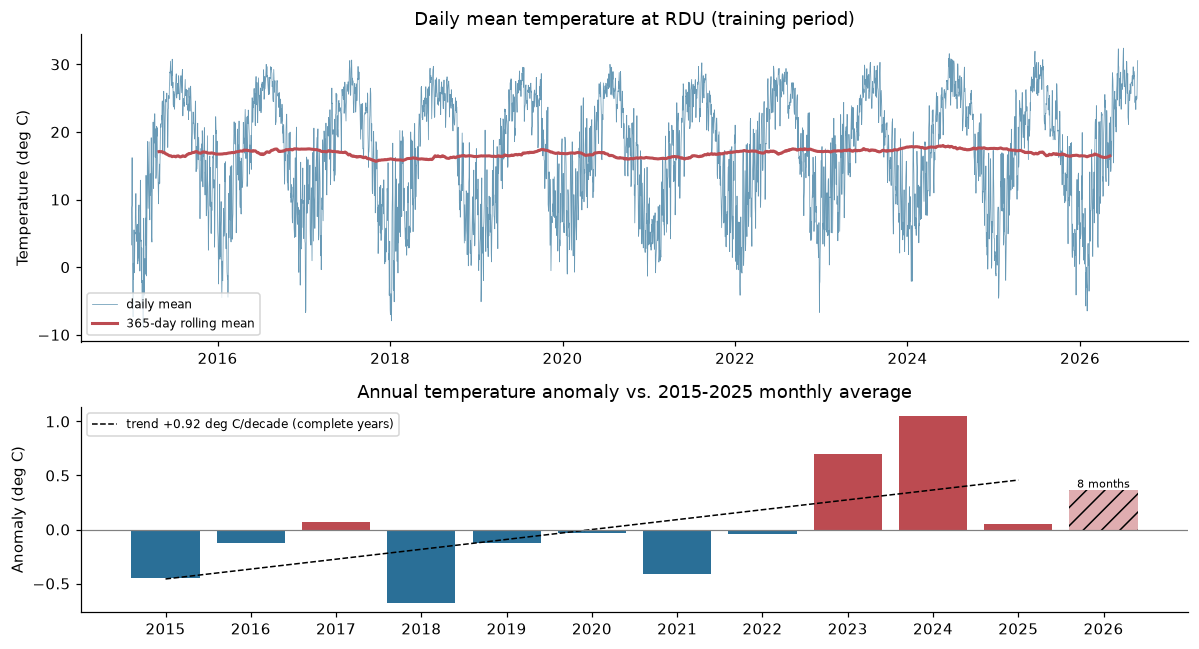

In [44]:
train = hourly[hourly["partition"].eq("train")].copy()
train_local = train.set_index("hour_local")  # Eastern-time index for calendar groupings
temp_local = train_local["temperature"]

# Daily means: local calendar days with >= 20 usable hours
MIN_HOURS_PER_DAY = 20
daily = temp_local.resample("D").agg(["mean", "count"])
daily_mean = daily["mean"].where(daily["count"].ge(MIN_HOURS_PER_DAY))
rolling_year = daily_mean.rolling(365, min_periods=300, center=True).mean()

# Annual anomaly: each month vs. the 2015-2025 average of that calendar month (removes the seasonal cycle)
monthly = temp_local.resample("MS").agg(["mean", "count"])
monthly_mean = monthly["mean"].where(monthly["count"].ge(0.9 * 24 * monthly.index.days_in_month))
in_complete_years = monthly_mean.index.year <= 2025
month_climatology = monthly_mean[in_complete_years].groupby(monthly_mean.index.month[in_complete_years]).mean()
monthly_anomaly = monthly_mean - month_climatology.reindex(monthly_mean.index.month).to_numpy()
annual = monthly_anomaly.groupby(monthly_anomaly.index.year).agg(anomaly="mean", months="count")
annual.index.name = "local_year"

complete = annual["months"].eq(12)
slope, intercept = np.polyfit(annual.index[complete], annual.loc[complete, "anomaly"], deg=1)
display(annual.round(2).T)
print(f"Linear trend over complete years {annual.index[complete].min()}-{annual.index[complete].max()}: "
      f"{10 * slope:+.2f} deg C per decade")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), gridspec_kw={"height_ratios": [1.5, 1]})
axes[0].plot(daily_mean.index, daily_mean, color="#2a6f97", linewidth=0.5, alpha=0.7, label="daily mean")
axes[0].plot(rolling_year.index, rolling_year, color="#bc4b51", linewidth=2, label="365-day rolling mean")
axes[0].set(title="Daily mean temperature at RDU (training period)", ylabel="Temperature (deg C)")
axes[0].legend(fontsize=8, loc="lower left")

bar_colors = np.where(annual["anomaly"] > 0, "#bc4b51", "#2a6f97")
bars = axes[1].bar(annual.index, annual["anomaly"], color=bar_colors)
for bar, months in zip(bars, annual["months"]):
    if months < 12:
        bar.set(alpha=0.45, hatch="//")
        axes[1].annotate(f"{months} months", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha="center", va="bottom", fontsize=7)
trend_years = annual.index[complete]
axes[1].plot(trend_years, intercept + slope * trend_years, "k--", linewidth=1,
             label=f"trend {10 * slope:+.2f} deg C/decade (complete years)")
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[1].set(title="Annual temperature anomaly vs. 2015-2025 monthly average", ylabel="Anomaly (deg C)")
axes[1].set_xticks(annual.index)
axes[1].legend(fontsize=8, loc="upper left")
fig.tight_layout()
save_fig(fig, "trend_daily_and_annual")
plt.show()

### 6a.2 Distribution of hourly temperatures

Temperatures are reported in whole °F and converted to °C, so the histogram uses 1 °F (5/9 °C) bins centred on those values. Other bin widths would create artificial gaps and spikes.

,temperature_deg_C
count,"102,126.000"
mean,16.880
std,9.330
min,-15.600
1%,-3.900
5%,0.600
25%,10.000
50%,18.300
75%,23.900
95%,30.600


,temperature_deg_C,hour_local
coldest hour,-15.600,2018-01-07 06:00:00-05:00
warmest hour,40.000,2024-07-05 13:00:00-04:00


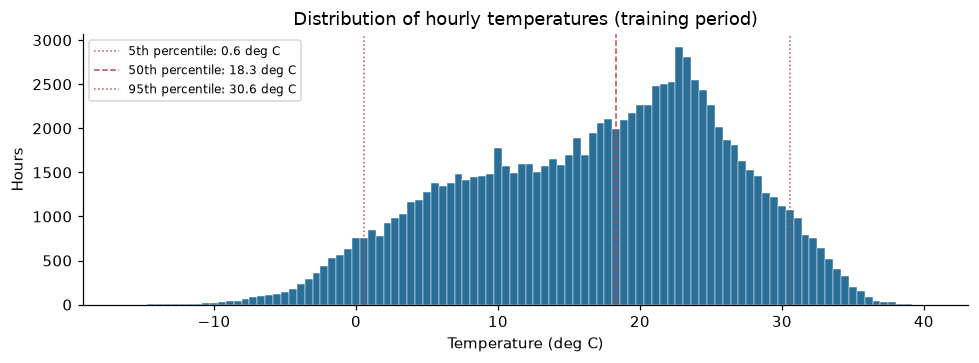

In [45]:
temperature = train["temperature"].dropna()
summary = temperature.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("temperature_deg_C")
extremes = pd.DataFrame({
    "temperature_deg_C": [temperature.min(), temperature.max()],
    "hour_local": [train.at[temperature.idxmin(), "hour_local"], train.at[temperature.idxmax(), "hour_local"]],
}, index=["coldest hour", "warmest hour"])
display(summary.round(2))
display(extremes)

# Values are whole deg F converted to deg C, so use 1 deg F wide bins centred on those values
fahrenheit = temperature * 9 / 5 + 32
bin_edges_f = np.arange(np.floor(fahrenheit.min()) - 0.5, np.ceil(fahrenheit.max()) + 1.5, 1)
bin_edges_c = (bin_edges_f - 32) * 5 / 9

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(temperature, bins=bin_edges_c, color="#2a6f97", edgecolor="white", linewidth=0.3)
for q, style in [(0.05, ":"), (0.5, "--"), (0.95, ":")]:
    ax.axvline(temperature.quantile(q), color="#bc4b51", linestyle=style, linewidth=1,
               label=f"{int(q * 100)}th percentile: {temperature.quantile(q):.1f} deg C")
ax.set(title="Distribution of hourly temperatures (training period)", xlabel="Temperature (deg C)",
       ylabel="Hours")
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "temperature_distribution")
plt.show()

### 6b. Seasonal and diurnal cycles

Two clocks drive the temperature at a given hour: the time of year and the local time of day. This section measures how strong each cycle is and whether they interact, i.e. whether the shape of the day changes with the season.

#### 6b.1 Month × hour heatmap

Mean temperature for every (month, local hour) combination. The September row is outlined.

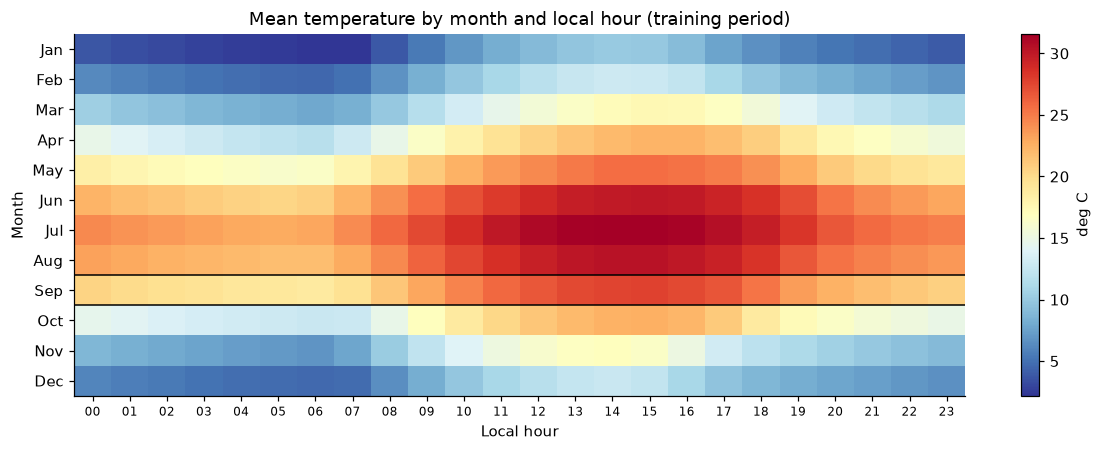

In [46]:
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
calendar = pd.DataFrame({
    "temperature": train_local["temperature"].to_numpy(),
    "month": train_local.index.month,
    "hour": train_local.index.hour,
}).dropna(subset=["temperature"])

month_hour = calendar.pivot_table(index="month", columns="hour", values="temperature", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11, 4.2))
image = ax.imshow(month_hour.to_numpy(), aspect="auto", cmap="RdYlBu_r")
ax.set_xticks(range(24), [f"{h:02d}" for h in range(24)], fontsize=8)
ax.set_yticks(range(12), MONTH_LABELS)
for edge in (7.5, 8.5):                                 # outline the September row
    ax.axhline(edge, color="black", linewidth=1)
ax.set(title="Mean temperature by month and local hour (training period)", xlabel="Local hour", ylabel="Month")
fig.colorbar(image, ax=ax, label="deg C")
fig.tight_layout()
save_fig(fig, "month_hour_heatmap")
plt.show()

#### 6b.2 Diurnal profile and daily range

- **Diurnal profile**: each month's mean hourly curve minus that month's mean, shown for one month per season plus September. If the curves overlap, the shape of the day barely depends on the season.
- **Daily range**: mean of (daily max − daily min) per month, using local days with at least 20 usable hours.

,mean_daily_min,mean_daily_max,mean_daily_range,coldest_local_hour,warmest_local_hour
month,,,,,
Jan,0.500,10.700,10.300,6,14
Feb,2.800,13.800,11.000,6,14
Mar,6.700,18.400,11.700,6,15
Apr,10.900,23.100,12.300,6,15
May,15.600,26.500,10.900,5,15
Jun,19.900,30.800,10.900,5,15
Jul,22.300,32.600,10.300,5,15
Aug,21.300,31.300,10.000,6,14
Sep,18.300,28.400,10.100,6,15


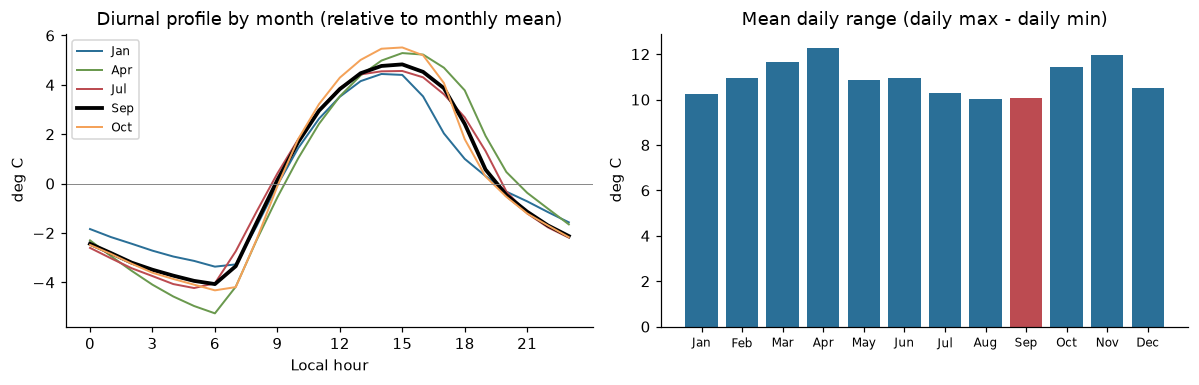

In [47]:
daily_stats = temp_local.resample("D").agg(["min", "max", "count"])
daily_stats = daily_stats[daily_stats["count"].ge(MIN_HOURS_PER_DAY)]
daily_stats["range"] = daily_stats["max"] - daily_stats["min"]

monthly_cycle = daily_stats.groupby(daily_stats.index.month).agg(
    mean_daily_min=("min", "mean"), mean_daily_max=("max", "mean"), mean_daily_range=("range", "mean"),
)
monthly_cycle["coldest_local_hour"] = month_hour.idxmin(axis=1)
monthly_cycle["warmest_local_hour"] = month_hour.idxmax(axis=1)
monthly_cycle.index = pd.Index(MONTH_LABELS, name="month")
display(monthly_cycle.round(1))

diurnal_shape = month_hour.sub(month_hour.mean(axis=1), axis=0)  # each month's day, relative to its own mean
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
PROFILE_MONTHS = {1: "#2a6f97", 4: "#6a994e", 7: "#bc4b51", 9: "black", 10: "#f4a259"}  # one month per season + Sep
for month, color in PROFILE_MONTHS.items():
    axes[0].plot(diurnal_shape.columns, diurnal_shape.loc[month], color=color,
                 linewidth=2.5 if month == 9 else 1.3, label=MONTH_LABELS[month - 1])
axes[0].axhline(0, color="grey", linewidth=0.6)
axes[0].set(title="Diurnal profile by month (relative to monthly mean)", xlabel="Local hour", ylabel="deg C")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend(fontsize=8, loc="upper left")

bar_colors = ["#bc4b51" if m == "Sep" else "#2a6f97" for m in monthly_cycle.index]
axes[1].bar(monthly_cycle.index, monthly_cycle["mean_daily_range"], color=bar_colors)
axes[1].set(title="Mean daily range (daily max - daily min)", ylabel="deg C")
axes[1].tick_params(axis="x", labelsize=8)
fig.tight_layout()
save_fig(fig, "diurnal_profile_by_month")
plt.show()

#### 6b.3 How much do calendar averages explain?

Each row predicts every hour with a simple calendar average and reports R² and RMSE on the training data:

- **hour only / month only**: one mean per local hour / per month.
- **month + hour (additive)**: a month effect plus an hour effect, fitted by least squares.
- **month × hour (interaction)**: one mean per (month, hour) cell.

If the interaction version is clearly better than the additive one, a linear model needs season × hour interaction terms. These are in-sample descriptions, not forecasts.

In [48]:
y = calendar["temperature"].to_numpy()


def fit_quality(fitted):
    residual = y - fitted
    return {"R2": 1 - (residual ** 2).sum() / ((y - y.mean()) ** 2).sum(), "RMSE_deg_C": np.sqrt((residual ** 2).mean())}


group_mean = lambda keys: calendar.groupby(keys)["temperature"].transform("mean").to_numpy()
additive_design = np.column_stack([
    np.ones(len(calendar)),
    pd.get_dummies(calendar[["month", "hour"]].astype("category"), drop_first=True).to_numpy(float),
])
additive_fit = additive_design @ np.linalg.lstsq(additive_design, y, rcond=None)[0]

calendar_fits = pd.DataFrame({
    "overall mean only": fit_quality(np.full_like(y, y.mean())),
    "hour only": fit_quality(group_mean("hour")),
    "month only": fit_quality(group_mean("month")),
    "month + hour (additive)": fit_quality(additive_fit),
    "month x hour (interaction)": fit_quality(group_mean(["month", "hour"])),
}).T
display(calendar_fits.round(3))

,R2,RMSE_deg_C
overall mean only,0.000,9.333
hour only,0.112,8.795
month only,0.612,5.813
month + hour (additive),0.724,4.903
month x hour (interaction),0.727,4.876


### 6c. The forecast window in past years (Sep 17–30, 2015–2025)

#### 6c.1 What the window usually looks like

- Hourly temperature for every year (grey) and the mean across years (black).
- Daily mean temperature per year, the mean across years, and a straight-line fit of that mean (the seasonal cooling within the window).
- Per-year summary: mean, min, max, mean daily range, and how much warmer or colder than the average window each year was.

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
mean,21.700,23.300,23.000,23.300,23.800,18.000,21.500,20.800,20.100,24.000,23.000
min,13.900,18.300,12.800,16.100,10.000,6.700,10.000,8.900,12.800,17.800,15.000
max,30.600,32.800,32.800,31.100,34.400,28.300,31.700,36.100,28.900,30.600,34.400
mean_daily_range,8.100,6.700,11.500,8.400,12.500,8.700,10.700,13.100,8.100,7.300,9.700
missing_hours,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
anomaly_vs_all_years,-0.300,1.200,0.900,1.300,1.800,-4.100,-0.600,-1.200,-1.900,1.900,1.000


Average of all years: 22.0 deg C; daily mean falls 0.07 deg C/day (0.9 deg C from Sep 17 to Sep 30)
Spread between years: window means range from 18.0 to 24.0 deg C


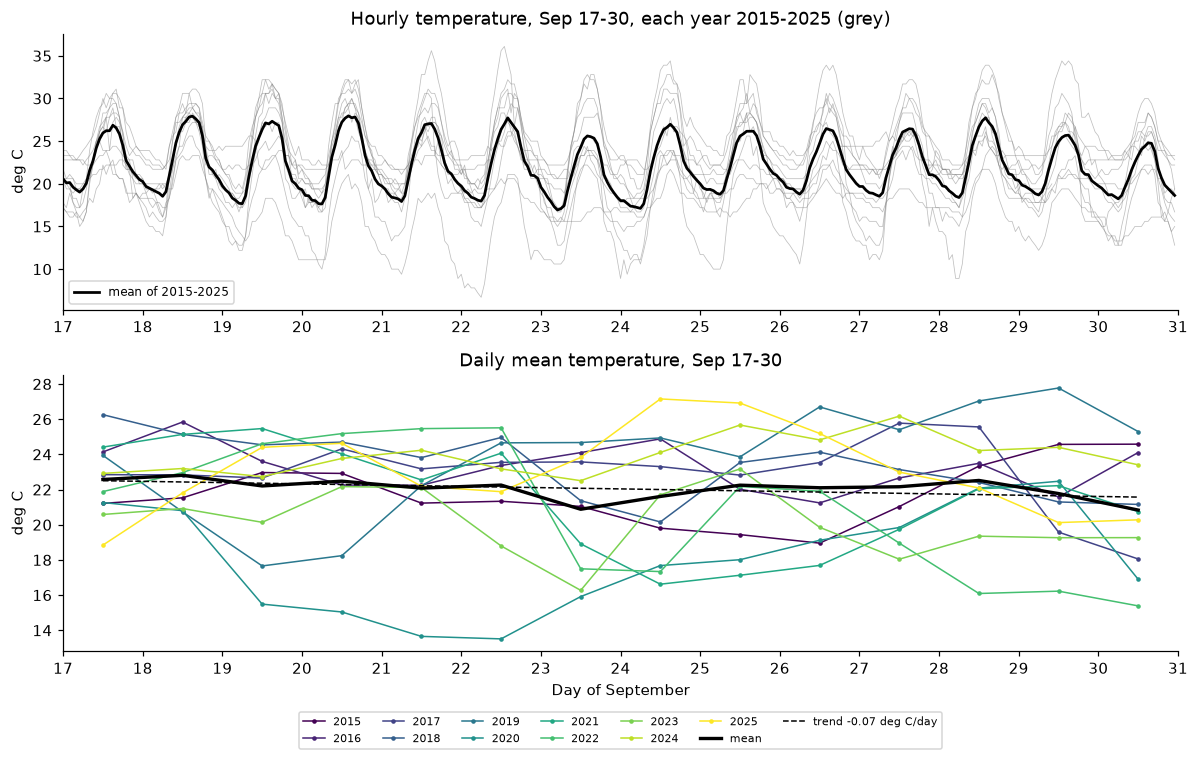

In [49]:
WINDOW_DAYS = 14
HISTORY_YEARS = list(range(2015, 2026))  # Sep 17-30, 2026 is the forecast itself


def local_window(year, start_day=17, days=WINDOW_DAYS, pad_days=0):
    """Hourly Eastern-time timestamps from Sep `start_day` of `year`, optionally padded on both sides."""
    start = pd.Timestamp(year=year, month=9, day=start_day, tz=NY) - pd.Timedelta(days=pad_days)
    return pd.date_range(start, periods=24 * (days + 2 * pad_days), freq="h")


# One column per year, one row per hour of the 14-day window (0 = 12am Sep 17)
windows = pd.DataFrame({year: temp_local.reindex(local_window(year)).to_numpy() for year in HISTORY_YEARS})
windows.index.name = "hour_of_window"
day_in_window = windows.index // 24 + 1
daily_window = windows.groupby(day_in_window).mean()  # 14 days x years

window_summary = pd.DataFrame({
    "mean": windows.mean(),
    "min": windows.min(),
    "max": windows.max(),
    "mean_daily_range": (windows.groupby(day_in_window).max() - windows.groupby(day_in_window).min()).mean(),
    "missing_hours": windows.isna().sum(),
})
window_summary["anomaly_vs_all_years"] = window_summary["mean"] - window_summary["mean"].mean()
window_summary.index.name = "year"
display(window_summary.round(1).T)

mean_daily = daily_window.mean(axis=1)
cooling_per_day, cooling_intercept = np.polyfit(mean_daily.index, mean_daily, deg=1)
print(f"Average of all years: {windows.stack().mean():.1f} deg C; "
      f"daily mean falls {-cooling_per_day:.2f} deg C/day ({-13 * cooling_per_day:.1f} deg C from Sep 17 to Sep 30)")
print(f"Spread between years: window means range from {window_summary['mean'].min():.1f} "
      f"to {window_summary['mean'].max():.1f} deg C")

window_days = 17 + windows.index / 24  # x-axis in September days
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for year in HISTORY_YEARS:
    axes[0].plot(window_days, windows[year], color="grey", linewidth=0.5, alpha=0.5)
axes[0].plot(window_days, windows.mean(axis=1), color="black", linewidth=1.8, label="mean of 2015-2025")
axes[0].set(title="Hourly temperature, Sep 17-30, each year 2015-2025 (grey)", ylabel="deg C")
axes[0].legend(fontsize=8, loc="lower left")

year_colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(HISTORY_YEARS)))
for color, year in zip(year_colors, HISTORY_YEARS):
    axes[1].plot(16.5 + daily_window.index, daily_window[year], color=color, linewidth=1, marker="o", markersize=2,
                 label=str(year))
axes[1].plot(16.5 + mean_daily.index, mean_daily, color="black", linewidth=2.2, label="mean")
axes[1].plot(16.5 + mean_daily.index, cooling_intercept + cooling_per_day * mean_daily.index, "k--", linewidth=1,
             label=f"trend {cooling_per_day:+.2f} deg C/day")
axes[1].set(title="Daily mean temperature, Sep 17-30", xlabel="Day of September", ylabel="deg C")
axes[1].legend(fontsize=7, ncol=7, loc="upper center", bbox_to_anchor=(0.5, -0.2))
for ax in axes:
    ax.set_xticks(range(17, 32))
    ax.set_xlim(17, 31)
fig.tight_layout()
save_fig(fig, "sep17_30_history")
plt.show()

#### 6c.2 Two naive baselines, scored on past windows

Each past year is forecast as if standing at 12am on Sep 17 of that year, using only data available at that moment, and the forecast is compared with what actually happened:

- **Climatology**: the mean of all *earlier* years at the same local hour, smoothed over ±3 days. Only past years are used, exactly like the real 2026 forecast (which can use 2015–2025). 2015 has no earlier year, so 2016–2025 are scored. Early years rely on few past years, which makes this baseline slightly pessimistic.
- **Persistence**: repeat the last observed day (Sep 16) for all 14 days.

Any model built later has to beat these numbers under the same rule (only data before the forecast start). The error is also broken down by forecast day.

,RMSE,MAE,bias
baseline,,,
climatology (earlier years),3.750,2.970,0.090
persistence (repeat Sep 16),4.240,3.290,-0.260


baseline,earlier_years_used,climatology (earlier years),persistence (repeat Sep 16)
year,,,
2016,1,3.530,2.360
2017,2,3.020,2.580
2018,3,2.230,3.310
2019,4,4.240,3.720
2020,5,5.970,4.460
2021,6,3.690,5.280
2022,7,4.280,4.370
2023,8,2.930,4.970
2024,9,3.150,4.690


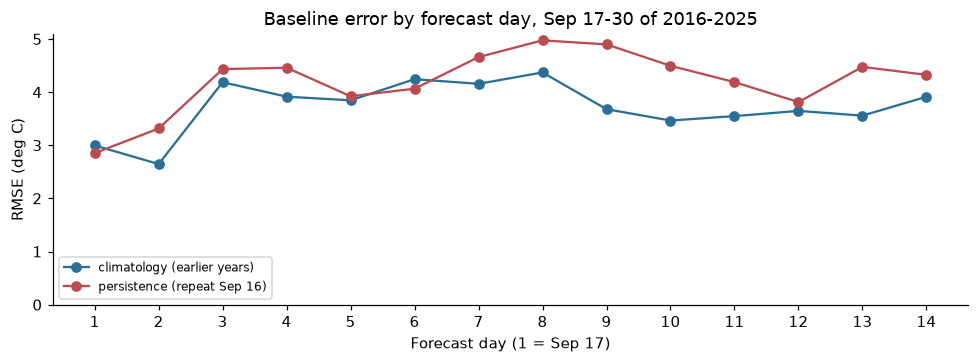

In [51]:
CONTEXT_DAYS = 3  # climatology for a given day uses +-3 days of the earlier years, at the same local hour

padded = pd.DataFrame({
    year: temp_local.reindex(local_window(year, pad_days=CONTEXT_DAYS)).to_numpy() for year in HISTORY_YEARS
})
SCORED_YEARS = HISTORY_YEARS[1:]  # 2015 has no earlier year to build a climatology from


def climatology_forecast(year):
    """Mean of all EARLIER years at the same local hour, smoothed over +-3 days (past data only)."""
    earlier_years = [y for y in HISTORY_YEARS if y < year]
    history = padded[earlier_years].mean(axis=1).to_numpy().reshape(-1, 24)  # days x hours
    smoothed = pd.DataFrame(history).rolling(2 * CONTEXT_DAYS + 1, center=True, min_periods=1).mean()
    return smoothed.to_numpy()[CONTEXT_DAYS:CONTEXT_DAYS + WINDOW_DAYS].ravel()


def persistence_forecast(year):
    """Repeat the last observed day (Sep 16) for all 14 days."""
    last_day = temp_local.reindex(local_window(year, start_day=16, days=1))
    return np.tile(last_day.interpolate(limit_direction="both").to_numpy(), WINDOW_DAYS)


BASELINES = {"climatology (earlier years)": climatology_forecast, "persistence (repeat Sep 16)": persistence_forecast}
baseline_errors = pd.concat([
    pd.DataFrame({"year": year, "baseline": name, "lead_day": day_in_window,
                  "error": windows[year].to_numpy() - forecast(year)})
    for year in SCORED_YEARS for name, forecast in BASELINES.items()
]).dropna(subset=["error"])


def rmse(errors):
    return float(np.sqrt(np.mean(np.square(errors))))


baseline_overall = baseline_errors.groupby("baseline")["error"].agg(
    RMSE=rmse, MAE=lambda e: e.abs().mean(), bias="mean",
)
rmse_by_year = baseline_errors.groupby(["year", "baseline"])["error"].apply(rmse).unstack()
rmse_by_year.insert(0, "earlier_years_used", [SCORED_YEARS.index(y) + 1 for y in rmse_by_year.index])
rmse_by_lead = baseline_errors.groupby(["lead_day", "baseline"])["error"].apply(rmse).unstack()
display(baseline_overall.round(2))
display(rmse_by_year.round(2))

fig, ax = plt.subplots(figsize=(9, 3.4))
for (name, values), color in zip(rmse_by_lead.items(), ["#2a6f97", "#bc4b51"]):
    ax.plot(values.index, values, marker="o", color=color, label=name)
ax.set(title=f"Baseline error by forecast day, Sep 17-30 of {SCORED_YEARS[0]}-{SCORED_YEARS[-1]}", xlabel="Forecast day (1 = Sep 17)",
       ylabel="RMSE (deg C)")
ax.set_xticks(range(1, WINDOW_DAYS + 1))
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "baseline_rmse_by_day")
plt.show()

### 6d. How long does a weather anomaly last?

The **anomaly** is the temperature minus its climatology (the training-period average for that day of year and local hour, smoothed over ±7 days). It measures how much warmer or colder than normal an hour is.

The plot shows the correlation between the value now and the value *k* hours later, computed on the complete hourly grid:

- **Raw temperature** stays correlated for weeks only because of the seasonal and daily cycles.
- **The anomaly** shows how long the weather itself is remembered, i.e. how long the state at the forecast start (12am Sep 17) can help before the forecast falls back to climatology. The Aug–Oct curve only uses starting hours in the forecast season.

The climatology uses all training years because this is a description, not a scored forecast.

,temperature,anomaly (all months),anomaly (Aug-Oct starts)
1 hour,0.990,0.980,0.960
1 day,0.890,0.570,0.580
2 days,0.810,0.270,0.300
3 days,0.780,0.160,0.180
5 days,0.760,0.080,0.050
7 days,0.750,0.060,0.010
10 days,0.730,0.020,0.000
14 days,0.740,0.070,0.040


Typical size of an anomaly (std): all months 4.7 deg C, Aug-Oct 3.4 deg C
Aug-Oct anomaly correlation drops below 1/e after 34 hours (1.4 days)


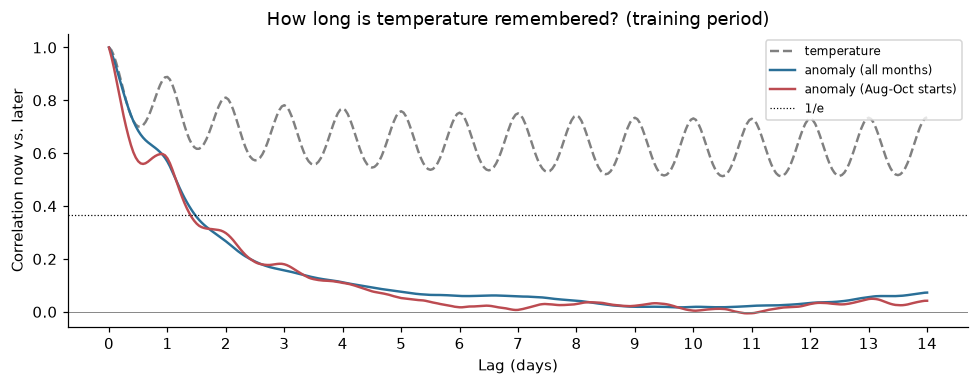

In [52]:
CLIMATOLOGY_HALF_WINDOW = 7  # smooth the day-of-year climatology over +-7 days
MAX_LAG_HOURS = 14 * 24

# Climatology: training average for each (day of year, local hour), smoothed across neighbouring days
local_index = train.index.tz_convert(NY)
day_of_year, local_hour = local_index.dayofyear.to_numpy(), local_index.hour.to_numpy()
raw_climatology = train["temperature"].groupby([day_of_year, local_hour]).mean().unstack()  # 366 days x 24 hours
wrapped = pd.concat([raw_climatology.iloc[-CLIMATOLOGY_HALF_WINDOW:], raw_climatology,
                     raw_climatology.iloc[:CLIMATOLOGY_HALF_WINDOW]])  # wrap Dec <-> Jan before smoothing
climatology = (
    wrapped.rolling(2 * CLIMATOLOGY_HALF_WINDOW + 1, center=True, min_periods=1).mean()
    .iloc[CLIMATOLOGY_HALF_WINDOW:-CLIMATOLOGY_HALF_WINDOW]
)
anomaly = train["temperature"] - climatology.to_numpy()[day_of_year - 1, local_hour]

# Correlation between "now" and "k hours later" on the complete hourly grid
starts_aug_oct = local_index.month.isin([8, 9, 10])


def lagged_corr(series, lag, mask=None):
    later = series.shift(-lag)
    return series[mask].corr(later[mask]) if mask is not None else series.corr(later)


lags = np.arange(MAX_LAG_HOURS + 1)
memory = pd.DataFrame({
    "temperature": [lagged_corr(train["temperature"], k) for k in lags],
    "anomaly (all months)": [lagged_corr(anomaly, k) for k in lags],
    "anomaly (Aug-Oct starts)": [lagged_corr(anomaly, k, starts_aug_oct) for k in lags],
}, index=pd.Index(lags, name="lag_hours"))

checkpoints = {"1 hour": 1, "1 day": 24, "2 days": 48, "3 days": 72, "5 days": 120,
               "7 days": 168, "10 days": 240, "14 days": 336}
display(memory.loc[list(checkpoints.values())].set_axis(list(checkpoints), axis=0).round(2))
e_folding = memory.index[memory["anomaly (Aug-Oct starts)"] < 1 / np.e][0]
print(f"Typical size of an anomaly (std): all months {anomaly.std():.1f} deg C, "
      f"Aug-Oct {anomaly[starts_aug_oct].std():.1f} deg C")
print(f"Aug-Oct anomaly correlation drops below 1/e after {e_folding} hours ({e_folding / 24:.1f} days)")

fig, ax = plt.subplots(figsize=(9, 3.6))
styles = {"temperature": ("grey", "--"), "anomaly (all months)": ("#2a6f97", "-"),
          "anomaly (Aug-Oct starts)": ("#bc4b51", "-")}
for column, (color, line) in styles.items():
    ax.plot(memory.index / 24, memory[column], color=color, linestyle=line, linewidth=1.6, label=column)
ax.axhline(1 / np.e, color="black", linestyle=":", linewidth=0.8, label="1/e")
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="How long is temperature remembered? (training period)", xlabel="Lag (days)",
       ylabel="Correlation now vs. later")
ax.set_xticks(range(15))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "anomaly_memory")
plt.show()

## 7. Summary and handoff

### 7.1 Key numbers

All values below are computed from the objects created above, so they always match the rest of the notebook.

In [53]:
rejection_era = observed["source_era"].reindex(rejection_log.index)
qc_rejections = int(rejection_log["reason"].eq("quality code").sum())
key_numbers = pd.Series({
    "Raw observations (rows x columns)": f"{len(raw):,} x {raw.shape[1]}",
    "Variables kept": f"{len(MEASUREMENTS_CLEAN)} measurements + 3 flags",
    "Complete hourly grid": f"{len(hourly):,} hours",
    "Hours with no report": f"{len(missing_hours)} in {len(gap_summary)} gaps "
                            f"(longest {gap_summary['missing_hours'].max()} h)",
    "Values rejected": f"{len(rejection_log)} (quality codes {qc_rejections}, "
                       f"physical checks {len(rejection_log) - qc_rejections})",
    "Temperatures rejected": f"{int(rejection_log['variable'].eq('temperature').sum())}",
    "Rejections in era 413 (no quality codes)": f"{int(rejection_era.eq('413').sum())}",
    "Usable temperature labels": f"{int(hourly['target_available'].sum()):,} of {len(hourly):,}",
    "Train / validation hours": f"{int(hourly['partition'].eq('train').sum()):,} / "
                                f"{int(hourly['partition'].eq('validation').sum())}",
    "Climatology baseline RMSE (Sep 17-30, 2016-2025)":
        f"{baseline_overall.loc['climatology (earlier years)', 'RMSE']:.2f} deg C",
    "Persistence baseline RMSE (Sep 17-30, 2016-2025)":
        f"{baseline_overall.loc['persistence (repeat Sep 16)', 'RMSE']:.2f} deg C",
    "Typical anomaly size, Aug-Oct (std)": f"{anomaly[starts_aug_oct].std():.1f} deg C",
    "Anomaly memory, Aug-Oct (correlation < 1/e)": f"{e_folding} h ({e_folding / 24:.1f} days)",
}, name="value").rename_axis("item").to_frame()
display(key_numbers)

print("Outputs of this notebook:")
for path in [CLEAN_FILE, LOG_FILE, *sorted(FIG_DIR.glob("02_*.png"))]:
    print(f"  {path.relative_to(PROJECT_ROOT)}")

,value
item,
Raw observations (rows x columns),"102,471 x 226"
Variables kept,10 measurements + 3 flags
Complete hourly grid,"102,647 hours"
Hours with no report,176 in 59 gaps (longest 90 h)
Values rejected,"260 (quality codes 245, physical checks 15)"
Temperatures rejected,9
Rejections in era 413 (no quality codes),1
Usable temperature labels,"102,462 of 102,647"
Train / validation hours,"102,311 / 336"


Outputs of this notebook:
  data/interim/rdu_hourly_clean_2015-01-01_to_2026-09-16.csv
  data/interim/rdu_rejection_log.csv
  reports/figures/02_anomaly_memory.png
  reports/figures/02_baseline_rmse_by_day.png
  reports/figures/02_diurnal_profile_by_month.png
  reports/figures/02_missing_hours_by_year.png
  reports/figures/02_month_hour_heatmap.png
  reports/figures/02_sep17_30_history.png
  reports/figures/02_source_eras_by_year.png
  reports/figures/02_spike_examples.png
  reports/figures/02_temperature_distribution.png
  reports/figures/02_trend_daily_and_annual.png


### 7.2 Handoff to `03_feature_engineering.ipynb`

**Input:** `data/interim/rdu_hourly_clean_2015-01-01_to_2026-09-16.csv`

```python
pd.read_csv(path, index_col="hour_utc", parse_dates=["hour_utc"], dtype={"source_era": "string"})
```

**Conventions**

- **Index:** continuous UTC hours covering 12am Jan 1, 2015 – 11pm Sep 16, 2026 (Eastern). Calendar features use `hour_local`, converted with `pd.to_datetime(..., utc=True).dt.tz_convert("America/New_York")`.
- **Target:** `temperature` (°C). The 185 missing values are not interpolated and are excluded from training targets. `temperature_raw` is for auditing only and is never a feature.
- **Forecast task:** one forecast issued at 12am Sep 17, 2026 for the next 336 hours. A feature is allowed only if it is known at the forecast start: calendar terms, lead time, and states observed before the start. Dew point, pressure, wind and cloud cover are unknown in the future, so they can only enter as values observed at the forecast start.
- **Evaluation:** backtests train only on data before each forecast start (as in 6c). Baselines to beat on Sep 17–30, 2016–2025: climatology 3.75 °C and persistence 4.24 °C RMSE. The validation window (Sep 3–16, 2026) stays untouched until the final model check.
- **Feature groups to build:** seasonal cycle (day of year), diurnal cycle (local hour), anomaly at the forecast start combined with lead time (so its weight can decay), recent-period anomaly, and optionally a few start-time weather states.